In [ ]:
import pandas as pd
data=pd.read_csv("retail_sales_dirty_realworld_31200_rows.csv")
df=data

In [ ]:
df=data

In [ ]:
df.shape

(31200, 16)

# **Data Cleaning**

In [ ]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Customer ID,1877
Customer Name,1877
City,3600
Region,2323
Segment,0
Category,0
Product,0
Quantity,0


In [ ]:
df=df.dropna(subset=["Customer ID"])

In [ ]:
df["City"]=df["City"].fillna(df["City"].mode()[0])

In [ ]:
df["Region"]=df["Region"].fillna(df["Region"].mode()[0])

In [ ]:
df["Payment Method"]=df["Payment Method"].fillna(df["Payment Method"].mode()[0])

In [ ]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Customer ID,1877
Customer Name,1877
City,0
Region,0
Segment,0
Category,0
Product,0
Quantity,0


In [ ]:
df["City"].unique()

array(['Ricemouth', 'Lake Ralphton', 'Edwardsview', ..., 'Dennisborough',
       'New Glen', 'Colonfurt'], dtype=object)

In [ ]:
df["Region"].unique()

array(['South', 'West', 'East', 'North', 'WEST', 'north', 'south',
       'SOUTH'], dtype=object)

In [ ]:
df["Region"]=df["Region"].str.strip().str.title()

In [ ]:
df["Payment Method"].unique()

array(['Card', 'Net Banking', 'Cash', 'UPI', 'upi', ' card', 'Card ',
       'NET BANKING'], dtype=object)

In [ ]:
df["Payment Method"]=df["Payment Method"].str.strip().str.title().replace({"Upi":"UPI"})

In [ ]:
df["Payment Method"].unique()

array(['Card', 'Net Banking', 'Cash', 'UPI'], dtype=object)

In [ ]:
df["Order Date"]=pd.to_datetime(df["Order Date"],errors="coerce")
df=df.dropna(subset=["Order Date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29024 entries, 0 to 31199
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        29024 non-null  object        
 1   Order Date      29024 non-null  datetime64[ns]
 2   Customer ID     29024 non-null  object        
 3   Customer Name   29024 non-null  object        
 4   City            29024 non-null  object        
 5   Region          29024 non-null  object        
 6   Segment         29024 non-null  object        
 7   Category        29024 non-null  object        
 8   Product         29024 non-null  object        
 9   Quantity        29024 non-null  int64         
 10  Cost Price      29024 non-null  float64       
 11  Unit Price      29024 non-null  float64       
 12  Discount        29024 non-null  float64       
 13  Sales           29024 non-null  float64       
 14  Profit          29024 non-null  float64       
 15  Payment

In [ ]:
df.columns

Index(['Order ID', 'Order Date', 'Customer ID', 'Customer Name', 'City',
       'Region', 'Segment', 'Category', 'Product', 'Quantity', 'Cost Price',
       'Unit Price', 'Discount', 'Sales', 'Profit', 'Payment Method'],
      dtype='object')

In [ ]:
df["Sales"]=(df["Unit Price"]*df["Quantity"])*(1-df["Discount"])
df["Profit"]=df["Sales"]-(df["Cost Price"]*df["Quantity"])

# **1. Executive KPIs**

In [ ]:
#Total Revenue
total_revnue=df["Sales"].sum()
print(f"Total Revenue is {total_revnue:.2f}")

Total Revenue is 71329206.38


In [ ]:
#Total Profit
Total_Profit=df["Profit"].sum()
print(f"Total Profit is {Total_Profit:.2f}")

Total Profit is 31985937.04


In [ ]:
#Total Orders
Total_orders=df["Order ID"].nunique()
print(f"Total Orders are {Total_orders}")

Total Orders are 27913


In [ ]:
#Total Customers
Total_Customers=df["Customer ID"].nunique()
print(f"Total Customers are {Total_Customers}")

Total Customers are 8587


In [ ]:
#Average Order Value
avg_order_value = total_revnue/Total_orders
print(f"Average Order Value is {avg_order_value:.2f}")

Average Order Value is 2555.41


# **2. Sales Analysis**

In [ ]:
pd.options.display.float_format = "{:,.2f}".format


In [ ]:
#Best-selling products
best =df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
print("Best selling products are :",best.head(5))

Best selling products are : Product
Product_76    2,066,885.87
Product_18    1,634,983.49
Product_180   1,455,725.00
Product_102   1,280,258.61
Product_50    1,055,008.66
Name: Sales, dtype: float64


In [ ]:
#Top categories
Top =df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print("Top Categories are :",Top)

Top Categories are : Category
Furniture         16,147,139.44
Clothing          15,322,125.06
Electronics       13,817,098.25
Sports            13,135,298.96
Office Supplies   12,907,544.67
Name: Sales, dtype: float64


In [ ]:
#Monthly sales trend
df["Year"]=df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month_name()

monthly_sales_2023=df[df["Year"]==2023].groupby("Month")["Sales"].sum()
print(monthly_sales_2023)

Month
August      1,535,306.47
December    1,976,317.61
July        1,338,141.36
June        1,353,272.07
November    2,526,571.43
October     3,455,505.08
September   2,077,452.96
Name: Sales, dtype: float64


Top-performing months:
October ,
November,
september

In [ ]:
monthly_sales_2024=df[df["Year"]==2024].groupby("Month")["Sales"].sum()
print(monthly_sales_2024)

Month
April       1,684,067.26
August      2,237,512.96
December    1,721,049.24
February    1,850,539.93
January     1,683,651.71
July        2,581,523.49
June        1,678,107.72
March       1,653,151.88
May         1,593,255.60
November    1,808,094.18
October     1,831,557.25
September   1,331,676.88
Name: Sales, dtype: float64


Top-performing months:

july,
october,
november

In [ ]:
monthly_sales_2025=df[df["Year"]==2025].groupby("Month")["Sales"].sum()
print(monthly_sales_2025)

Month
April       1,355,125.99
August      2,634,058.36
December    1,501,604.82
February    2,539,697.31
January     2,269,604.99
July        2,629,894.77
June        1,176,464.97
March       2,257,808.43
May         2,265,506.96
November    2,088,176.00
October     1,822,324.07
September   1,825,356.31
Name: Sales, dtype: float64


Top-performing months:

february,
january,
may,
march

In [ ]:
monthly_sales_2026=df[df["Year"]==2026].groupby("Month")["Sales"].sum()
print(monthly_sales_2026)


Month
April      1,447,679.11
February   1,756,956.33
January    1,315,588.28
June       1,115,491.18
March      1,887,807.05
May        3,523,306.38
Name: Sales, dtype: float64


Top-performing months:

may,
march

In [ ]:
#Yearly growth
year_sales=df.groupby("Year")["Sales"].sum()
yearly_growth=year_sales.pct_change()*100
summary =pd.DataFrame({
    "Sales":year_sales,
    "Growth %":yearly_growth
})
print(summary)

             Sales  Growth %
Year                        
2023 14,262,566.97       NaN
2024 21,654,188.11     51.83
2025 24,365,622.97     12.52
2026 11,046,828.33    -54.66


# **3.Customer Analysis**

In [ ]:
#Top customers
top_cust=df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False)
print(top_cust.head(10))

Customer ID
CUST6203   1,405,243.72
CUST6420   1,083,416.67
CUST9734     877,555.20
CUST3206     674,111.23
CUST5148     636,359.07
CUST7463     602,133.47
CUST6548     601,004.51
CUST1107     502,354.31
CUST7666     500,221.80
CUST6130     499,995.00
Name: Sales, dtype: float64


In [ ]:
#Customer segments
df["Customer Sales"]=df.groupby("Customer ID")["Sales"].transform("sum")
df["Customer Segments"]=pd.qcut(
    df["Customer Sales"],
    q=3,
    labels=["Low Customer","Medium Customer","Premimum Customer"]
)
print(df[["Customer ID","Customer Sales","Customer Segments"]])

      Customer ID  Customer Sales Customer Segments
0        CUST6734        3,365.10      Low Customer
1        CUST1769          506.02      Low Customer
2        CUST9666        5,875.68   Medium Customer
3        CUST2899        3,986.24      Low Customer
4        CUST9433        4,656.25   Medium Customer
...           ...             ...               ...
31195    CUST3025        3,539.09      Low Customer
31196    CUST3381        2,213.34      Low Customer
31197    CUST2997        2,768.34      Low Customer
31198    CUST7238        7,280.69   Medium Customer
31199    CUST2091        3,196.23      Low Customer

[31200 rows x 3 columns]


In [ ]:
#Repeat customers
cust_orders =df.groupby("Customer ID")["Order ID"].nunique()
repeat_Cust= cust_orders[cust_orders>1].count()
print("Repeat Customers:",repeat_Cust)



Repeat Customers: 7365


In [ ]:
#High-value customers
high=df["Customer Segments"].value_counts()["Premimum Customer"]
print("High Value Customers:",high)

High Value Customers: 9671


# **4. Profit Analysis**

In [ ]:
#Most profitable products
pro=df.groupby("Product")["Profit"].sum().sort_values(ascending=False)
print(pro.head(10))

Product
Product_76    1,720,037.72
Product_18    1,468,784.20
Product_180   1,196,532.35
Product_102   1,137,787.59
Product_50      912,621.93
Product_63      823,550.29
Product_8       685,406.88
Product_41      665,786.10
Product_134     597,497.22
Product_187     581,196.74
Name: Profit, dtype: float64


In [ ]:
#Least profitable products
least=df.groupby("Product")["Profit"].sum().sort_values(ascending=True)
print(least.head(10))

Product
Product_1     29,757.86
Product_17    33,139.90
Product_70    37,250.15
Product_148   37,728.36
Product_105   38,869.32
Product_127   41,762.12
Product_171   43,320.78
Product_31    44,289.76
Product_174   45,041.74
Product_129   45,673.31
Name: Profit, dtype: float64


In [ ]:
#Profit by category
pc =df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
print(pc)


Category
Furniture         8,356,746.13
Clothing          6,834,752.41
Electronics       6,321,961.61
Sports            5,333,440.40
Office Supplies   5,139,036.49
Name: Profit, dtype: float64


In [ ]:
#Profit by region
pr =df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
print(pr)

Region
North   9,268,692.06
East    8,653,906.21
West    8,510,476.57
South   5,552,862.20
Name: Profit, dtype: float64


# **5. Regional Analysis**

In [ ]:
#Best performing region
BFR =df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print(BFR.head(1))

Region
North   20,781,976.68
Name: Sales, dtype: float64


In [ ]:
#Worst performing region
WFR =df.groupby("Region")["Sales"].sum().sort_values(ascending=True)
print(WFR.head(1))

Region
South   15,550,315.65
Name: Sales, dtype: float64


In [ ]:
#Revenue by city/Region
result =pd.pivot_table(
    data=df,
    index="City",
    columns="Region",
    values="Sales",
    aggfunc="sum",
    fill_value=0
)
print(result)

Region             East    North    South     West
City                                              
Aaronborough       0.00     0.00 1,274.19     0.00
Aaronbury        359.46     0.00     0.00     0.00
Aaronchester       0.00 2,794.94     0.00 1,126.74
Aaronhaven     1,692.41     0.00     0.00     0.00
Aaronland          0.00 1,977.78 4,508.13     0.00
...                 ...      ...      ...      ...
Zimmermanfurt      0.00     0.00     0.00 3,131.01
Zimmermanhaven     0.00     0.00 1,463.02     0.00
Zunigafort         0.00   198.06     0.00     0.00
Zunigaton          0.00   332.09     0.00 2,622.02
Zunigaview         0.00     0.00 1,355.10     0.00

[15925 rows x 4 columns]


# **6. Discount Analysis**

In [ ]:
#Does discount increase sales
df["Discount Segment"]=df["Discount"].apply(
    lambda x: "Low Discount" if x<=0.10
    else "Medium Discount" if x<=0.20
    else "High Discount"
)
result = df.groupby("Discount Segment").agg(
    Orders=("Sales", "count"),
    Avg_Sales=("Sales", "mean"),
    Total_Sales=("Sales", "sum")
).sort_values("Total_Sales",ascending=True)

print(result)


                  Orders  Avg_Sales   Total_Sales
Discount Segment                                 
High Discount       4852   1,800.08  8,733,992.71
Medium Discount     9712   2,345.77 22,782,088.00
Low Discount       14460   2,753.33 39,813,125.66


In [ ]:
#Does discount increase sales
print(df["Discount"].corr(df["Sales"]))

-0.021885160416220198


There is no significant relationship between discount and sales. Increasing discounts does not appear to increase sales in this dataset.

In [ ]:
#Does discount reduce profit?
result=df.groupby("Discount Segment").agg(
    orders=("Profit","count"),
    Avg_Profit=("Profit","mean"),
    Total_Profit=("Profit","sum")
).sort_values("Total_Profit",ascending=True)
print(result)

                  orders  Avg_Profit  Total_Profit
Discount Segment                                  
High Discount       4852      392.62  1,904,982.40
Medium Discount     9712      944.04  9,168,473.30
Low Discount       14460    1,446.23 20,912,481.33


In [ ]:
#Does discount reduce profit?
print(df["Discount"].corr(df["Profit"]))

-0.027480158744317484


Discounts have almost no impact on profit, as the correlation is very close to zero

# **7. Time Analysis**

In [ ]:
#Sales by month year 2023
month_sales_23=df[df["Year"]==2023].groupby("Month")["Sales"].sum()
print(month_sales_23)

Month
August      1,535,306.47
December    1,976,317.61
July        1,338,141.36
June        1,353,272.07
November    2,526,571.43
October     3,455,505.08
September   2,077,452.96
Name: Sales, dtype: float64


In [ ]:
#Sales by month year 2024
month_sales_24=df[df["Year"]==2024].groupby("Month")["Sales"].sum()
print(month_sales_24)

Month
April       1,684,067.26
August      2,237,512.96
December    1,721,049.24
February    1,850,539.93
January     1,683,651.71
July        2,581,523.49
June        1,678,107.72
March       1,653,151.88
May         1,593,255.60
November    1,808,094.18
October     1,831,557.25
September   1,331,676.88
Name: Sales, dtype: float64


In [ ]:
#Sales by month year 2025
month_sales_25=df[df["Year"]==2025].groupby("Month")["Sales"].sum()
print(month_sales_25)

Month
April       1,355,125.99
August      2,634,058.36
December    1,501,604.82
February    2,539,697.31
January     2,269,604.99
July        2,629,894.77
June        1,176,464.97
March       2,257,808.43
May         2,265,506.96
November    2,088,176.00
October     1,822,324.07
September   1,825,356.31
Name: Sales, dtype: float64


In [ ]:
#Sales by month year 2026
month_sales_26=df[df["Year"]==2026].groupby("Month")["Sales"].sum()
print(month_sales_26)

Month
April      1,447,679.11
February   1,756,956.33
January    1,315,588.28
June       1,115,491.18
March      1,887,807.05
May        3,523,306.38
Name: Sales, dtype: float64


In [ ]:
#Sales by month
df["Year Month"]=df["Order Date"].dt.to_period("M")
sales_month=df.groupby("Year Month")["Sales"].sum()
print(sales_month)

Year Month
2023-06   1,353,272.07
2023-07   1,338,141.36
2023-08   1,535,306.47
2023-09   2,077,452.96
2023-10   3,455,505.08
2023-11   2,526,571.43
2023-12   1,976,317.61
2024-01   1,683,651.71
2024-02   1,850,539.93
2024-03   1,653,151.88
2024-04   1,684,067.26
2024-05   1,593,255.60
2024-06   1,678,107.72
2024-07   2,581,523.49
2024-08   2,237,512.96
2024-09   1,331,676.88
2024-10   1,831,557.25
2024-11   1,808,094.18
2024-12   1,721,049.24
2025-01   2,269,604.99
2025-02   2,539,697.31
2025-03   2,257,808.43
2025-04   1,355,125.99
2025-05   2,265,506.96
2025-06   1,176,464.97
2025-07   2,629,894.77
2025-08   2,634,058.36
2025-09   1,825,356.31
2025-10   1,822,324.07
2025-11   2,088,176.00
2025-12   1,501,604.82
2026-01   1,315,588.28
2026-02   1,756,956.33
2026-03   1,887,807.05
2026-04   1,447,679.11
2026-05   3,523,306.38
2026-06   1,115,491.18
Freq: M, Name: Sales, dtype: float64


In [ ]:
#Sales by quarter
df["quater"]=df["Order Date"].dt.quarter
quater_sales =df.groupby("quater")["Sales"].sum()
print(quater_sales)

quater
1   17,214,805.91
2   17,192,277.24
3   18,190,923.54
4   18,731,199.69
Name: Sales, dtype: float64


In [ ]:
#Seasonal trends
seasonal_trends =pd.pivot_table(
    data=df,
    index="Month",
    columns="Year",
    values="Sales",
    aggfunc="sum",
    fill_value=0
)
print(seasonal_trends)

Year              2023         2024         2025         2026
Month                                                        
April             0.00 1,684,067.26 1,355,125.99 1,447,679.11
August    1,535,306.47 2,237,512.96 2,634,058.36         0.00
December  1,976,317.61 1,721,049.24 1,501,604.82         0.00
February          0.00 1,850,539.93 2,539,697.31 1,756,956.33
January           0.00 1,683,651.71 2,269,604.99 1,315,588.28
July      1,338,141.36 2,581,523.49 2,629,894.77         0.00
June      1,353,272.07 1,678,107.72 1,176,464.97 1,115,491.18
March             0.00 1,653,151.88 2,257,808.43 1,887,807.05
May               0.00 1,593,255.60 2,265,506.96 3,523,306.38
November  2,526,571.43 1,808,094.18 2,088,176.00         0.00
October   3,455,505.08 1,831,557.25 1,822,324.07         0.00
September 2,077,452.96 1,331,676.88 1,825,356.31         0.00


# **8. Advanced EDA**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

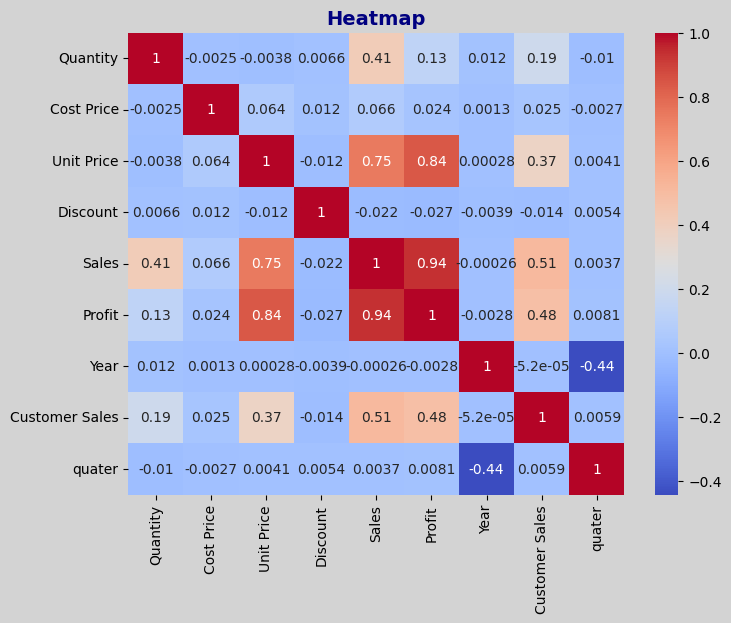

In [ ]:
#Correlation heatmap
plt.figure(figsize=(8,6))
corr=df.corr(numeric_only=True)
ax=sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.gcf().set_facecolor("lightgray")
plt.title(
    "Heatmap",
    fontsize=14,
    fontweight="bold",
    color="navy"
)
plt.show()


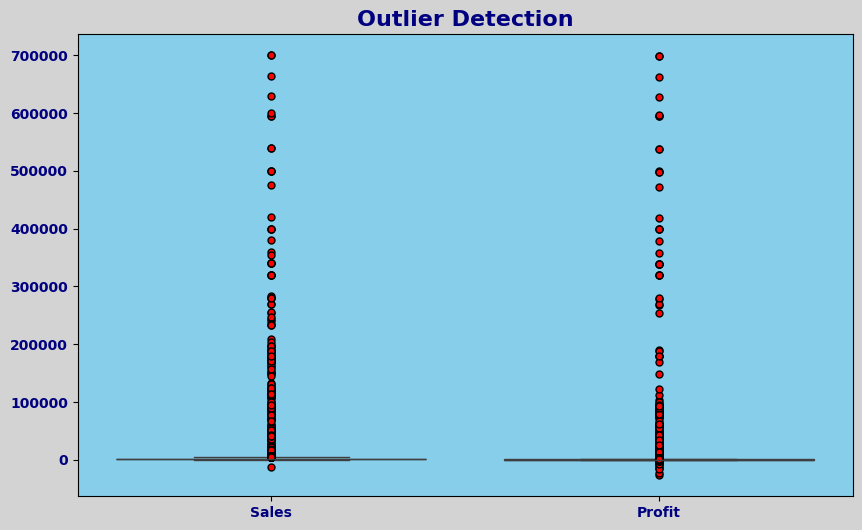

In [ ]:
#Boxplots
plt.figure(figsize=(10, 6))

ax=sns.boxplot(
    data=df[["Sales", "Profit"]],
    flierprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 5
    }
)

plt.title(
    "Outlier Detection",
    fontsize=16,
    fontweight="bold",
    color="navy"
)
plt.gcf().set_facecolor("lightgray")
ax.set_facecolor("skyblue")
plt.xticks(
    fontweight="bold",

    color="navy"
)
plt.yticks(
    fontweight="bold",
    color="navy"
)
plt.show()


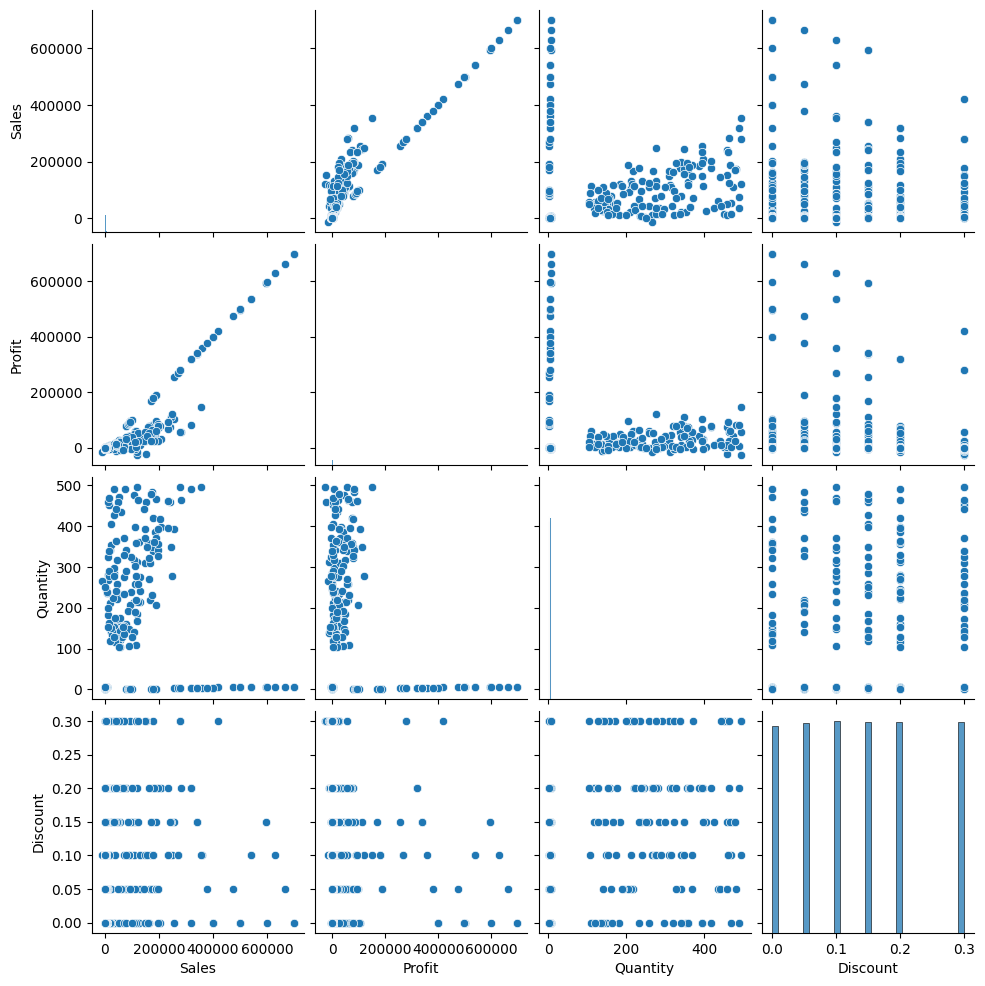

In [ ]:
#Pairwise relationships
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[["Sales", "Profit", "Quantity", "Discount"]]
)

plt.show()

In [ ]:
import numpy as np
import matplotlib.ticker as ticker

/tmp/ipykernel_29361/1713814223.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax=sns.lineplot(


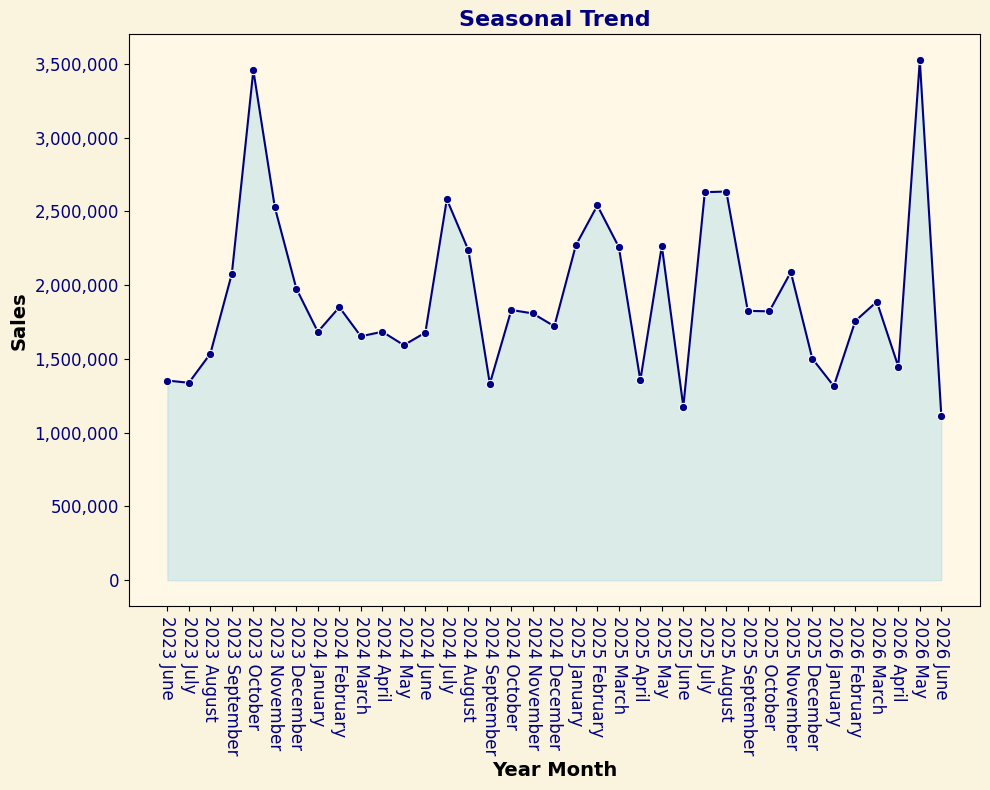

In [ ]:
#lineplot
df["Label"]=df["Order Date"].dt.strftime("%Y %B")
result=df.groupby(["Year Month","Label"])["Sales"].sum().reset_index().sort_values("Year Month")
x=np.arange(len(result))
plt.figure(figsize=(10,8))
ax=sns.lineplot(
    data=result,
    x="Label",
    y="Sales",
    marker="o",
    palette="deep",
    color="navy"
)
ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)
plt.gcf().set_facecolor("#FAF3DD")
ax.set_facecolor("#FFF8E7")
plt.title(
    "Seasonal Trend",
    fontsize=16,
    color="navy",
    fontweight="bold"
)
plt.fill_between(
    x,
    result["Sales"].values,
    color="skyblue",
    alpha=0.3
)
plt.xticks(
    rotation=-90,
    fontsize=12,
    color="navy"
)
plt.yticks(
    fontsize=12,
    color="navy"
)
plt.xlabel(
    "Year Month",
    color="black",
    fontsize=14,
    fontweight="bold"
)
plt.ylabel(
    "Sales",
    color="black",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# **9. Statistical Analysis**

**correlation tests**

**Pearson Correlation**

In [ ]:

df["Discount"].corr(df["Profit"], method="pearson")

np.float64(-0.027480158744317484)

Discounts have a very weak negative impact on profit, indicating that discounting is not a major driver of profit changes.

In [ ]:
df["Sales"].corr(df["Profit"])

np.float64(0.9362077866589552)

Sales and profit have a very strong positive relationship, meaning higher sales generally lead to higher profits.

In [ ]:
df["Quantity"].corr(df["Sales"])

np.float64(0.41441250012128367)

Selling more units contributes to higher sales, but quantity alone does not fully explain revenue growth.

**Spearman Correlation**

In [ ]:
df[["Sales","Profit","Discount","Quantity"]].corr(
    method="spearman"
)

,Sales,Profit,Discount,Quantity
Sales,1.00,0.79,-0.10,0.59
Profit,0.79,1.00,-0.33,0.38
Discount,-0.10,-0.33,1.00,-0.01
Quantity,0.59,0.38,-0.01,1.00


1.Higher discounts tend to reduce profit. Products with larger discounts generally earn lower profits.(-0.33)
2.Products generating higher sales usually generate higher profits as well.(0.79)
3.Discounts do not significantly increase sales and may even have a slight negative effect.(-0.10)
4.Selling more units generally leads to higher sales revenue.(0.59)
5.Higher quantities sold contribute to profit growth, but the impact is moderate.(0.38)

**Kendall Correlation**

In [ ]:
df[["Sales","Profit","Discount","Quantity"]].corr(
    method="kendall"
)

,Sales,Profit,Discount,Quantity
Sales,1.00,0.63,-0.07,0.45
Profit,0.63,1.00,-0.24,0.28
Discount,-0.07,-0.24,1.00,-0.00
Quantity,0.45,0.28,-0.00,1.00


1.Higher discounts tend to reduce profits, indicating that aggressive discounting may hurt profitability. (-0.24)
2.Products with higher sales generally generate higher profits, making sales growth an important driver of business performance. (0.63)
3.Discounts have little to no impact on increasing sales, suggesting customers are not highly influenced by discounts. (-0.07)
4.Selling more units contributes to higher sales revenue, showing quantity sold is an important sales driver. (0.45)
5.Higher quantities sold help increase profits, but the impact is moderate compared to sales. (0.28)

# **10.RFM Customer Segmentation**

In [ ]:
#Which customers purchased most recently?
latest=df["Order Date"].max()
last_pur=df.groupby("Customer ID")["Order Date"].max()
result=(latest-last_pur).dt.days
print(result.sort_values(ascending=True).head(10))

Customer ID
CUST1049    0
CUST4590    0
CUST8350    0
CUST3152    0
CUST9012    0
CUST1861    0
CUST5315    0
CUST2933    0
CUST3102    0
CUST3063    0
Name: Order Date, dtype: int64


In [ ]:
#Which customers have not purchased for a long time?
latest=df["Order Date"].max()
last_pur=df.groupby("Customer ID")["Order Date"].max()
result=(latest-last_pur).dt.days
print(result.sort_values(ascending=False).head(10))

Customer ID
CUST8593    1095
CUST9862    1095
CUST3305    1093
CUST4527    1093
CUST5206    1092
CUST3403    1092
CUST7003    1091
CUST9470    1091
CUST9971    1091
CUST5447    1089
Name: Order Date, dtype: int64


In [ ]:
#What is the average recency of customers?
latest=df["Order Date"].max()
last_pur=df.groupby("Customer ID")["Order Date"].max()
recency_days=(latest-last_pur).dt.days
avg_recency=recency_days.mean()
print(f"the average recency is {avg_recency:.2f} days")


the average recency is 298.08 days


**Frequency**

In [ ]:
#Which customers place orders most frequently?
frequency=df.groupby("Customer ID")["Order ID"].nunique().sort_values(ascending=False)
print(frequency.head(10))

Customer ID
CUST5389    12
CUST5552    12
CUST5067    11
CUST1761    11
CUST8964    11
CUST5852    10
CUST9852    10
CUST6184    10
CUST5175    10
CUST3486    10
Name: Order ID, dtype: int64


In [ ]:
#What percentage of customers are repeat buyers?
orders=df.groupby("Customer ID")["Order ID"].nunique()
repeat_buyers=(orders>1).sum()
total_cust=orders.count()
pct=(repeat_buyers/total_cust)*100
print(f"percentage of repeat customers is {pct:.2f}")



percentage of repeat customers is 85.77


**Monetary**

In [ ]:
#Which customers generate the highest revenue?
cust_revenue=df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False)
print(cust_revenue.head(10))

Customer ID
CUST6203   1,405,243.72
CUST6420   1,083,416.67
CUST9734     877,555.20
CUST3206     674,111.23
CUST5148     636,359.07
CUST7463     602,133.47
CUST6548     601,004.51
CUST1107     502,354.31
CUST7666     500,221.80
CUST6130     499,995.00
Name: Sales, dtype: float64


In [ ]:
#Which customers generate the highest profit?
cust_profit=df.groupby("Customer ID")["Profit"].sum().sort_values(ascending=False)
print(cust_profit.head(10))

Customer ID
CUST6203   1,399,555.56
CUST6420   1,074,861.35
CUST3206     666,468.92
CUST9734     652,595.13
CUST5148     630,514.97
CUST7463     597,593.62
CUST6548     596,659.18
CUST6130     499,646.60
CUST1107     498,626.18
CUST7666     497,634.93
Name: Profit, dtype: float64


**RFM Segments**

In [ ]:
#Who are the "Champions" customers?
latest=df["Order Date"].max()
last_pur=df.groupby("Customer ID")["Order Date"].max()
recency=(latest-last_pur).dt.days

frequency=df.groupby("Customer ID")["Order ID"].nunique()

monetary=df.groupby("Customer ID")["Sales"].sum()

rfm =pd.concat(
    [recency,frequency,monetary],
    axis=1
)
rfm.columns=[
    "recency",
    "frequency",
    "monetary"
]
champions =rfm[
    (rfm["recency"]<=rfm["recency"].quantile(0.25)) &
    (rfm["frequency"]>=rfm["frequency"].quantile(0.75))&
    (rfm["monetary"]>=rfm["monetary"].quantile(0.75))
]
print(champions)

             recency  frequency  monetary
Customer ID                              
CUST1001          50          8 13,433.88
CUST1008          71          7 13,730.32
CUST1026          34          5  9,408.93
CUST1034          16          4  9,034.33
CUST1059          57          5 13,744.71
...              ...        ...       ...
CUST9901          34          4 10,150.34
CUST9910          74          6  9,040.87
CUST9938          35          6  9,651.38
CUST9964          58          8  8,986.17
CUST9994          58          5 15,386.29

[668 rows x 3 columns]


In [ ]:
#Who are the "Loyal Customers"?
Loyal_customers=rfm[
    (rfm["recency"]<=rfm["recency"].quantile(0.50))&
    (rfm["frequency"]>=rfm["frequency"].quantile(0.75))
]
print(Loyal_customers)

             recency  frequency  monetary
Customer ID                              
CUST1000         142          4  4,468.57
CUST1001          50          8 13,433.88
CUST1003         207          5  5,544.06
CUST1008          71          7 13,730.32
CUST1014         100          4  4,626.99
...              ...        ...       ...
CUST9979          30          7  5,794.05
CUST9980          53          4  6,579.64
CUST9987          87          6  6,839.35
CUST9989         103          7  8,991.98
CUST9994          58          5 15,386.29

[2278 rows x 3 columns]


In [ ]:
#Which customers are "At Risk" of churn?
churn=rfm[
    (rfm["recency"]>=rfm["recency"].quantile(0.75)) &
    (rfm["frequency"]>=rfm["frequency"].quantile(0.75))&
    (rfm["monetary"]>=rfm["monetary"].quantile(0.75))
]
print(churn)

             recency  frequency  monetary
Customer ID                              
CUST1035         529          4 10,090.59
CUST1088         572          4 10,483.92
CUST1100         501          4  8,853.85
CUST1243         640          5  8,455.43
CUST1246         455          4  9,291.33
...              ...        ...       ...
CUST9463         502          5  7,216.35
CUST9644         446          4  8,480.67
CUST9749         611          4  9,939.33
CUST9793         494          4  8,135.55
CUST9924         604          5 14,837.88

[131 rows x 3 columns]


In [ ]:
#Which customers are "Lost Customers"?
lost_cust=rfm[
    (rfm["recency"]>=rfm["recency"].quantile(0.75)) &
    (rfm["frequency"]<=rfm["frequency"].quantile(0.25))&
    (rfm["monetary"]<=rfm["monetary"].quantile(0.25))
]
print(lost_cust)

             recency  frequency  monetary
Customer ID                              
CUST1005        1020          1  1,176.11
CUST1010         598          2  1,421.61
CUST1020         672          2  1,622.56
CUST1022         779          2    609.70
CUST1048         482          2  1,433.46
...              ...        ...       ...
CUST9967         543          1    786.55
CUST9968         753          1  1,731.25
CUST9971        1091          1    110.75
CUST9975         905          2  1,610.02
CUST9982         939          1    680.88

[803 rows x 3 columns]


In [ ]:
#What percentage of revenue comes from Champions?
champion_ids=champions.index
champions_revenue=df[df["Customer ID"].isin(champion_ids)]["Sales"].sum()
total_revenue=df["Sales"].sum()
pct=(champions_revenue/total_revenue)*100
print(f"champions revenue percentage is {pct:.2f}")

champions revenue percentage is 19.32


# **11. ABC Product Analysis**

In [ ]:
#Which products contribute to the first 80% of total revenue?
revenue =df.groupby("Product")["Sales"].sum().sort_values(ascending=False).reset_index()
revenue["pct"]=(revenue["Sales"]/df["Sales"].sum())*100
revenue["cum pct"]=revenue["pct"].cumsum()
revenue_80 =revenue[revenue["cum pct"]<=80]
print(revenue_80)



         Product        Sales  pct  cum pct
0     Product_76 2,066,885.87 2.90     2.90
1     Product_18 1,634,983.49 2.29     5.19
2    Product_180 1,455,725.00 2.04     7.23
3    Product_102 1,280,258.61 1.79     9.03
4     Product_50 1,055,008.66 1.48    10.50
..           ...          ...  ...      ...
122  Product_131   236,024.75 0.33    78.64
123  Product_172   234,060.98 0.33    78.97
124  Product_199   232,538.89 0.33    79.29
125   Product_21   231,111.46 0.32    79.62
126  Product_103   230,517.59 0.32    79.94

[127 rows x 4 columns]


In [ ]:
#Which products belong to Category A?
revenue["ABC"]=revenue["cum pct"].apply(
    lambda x: "A" if x<=80
    else "B" if x<= 95
    else "C"
)
print(revenue[revenue["ABC"]=="A"])

         Product        Sales  pct  cum pct ABC
0     Product_76 2,066,885.87 2.90     2.90   A
1     Product_18 1,634,983.49 2.29     5.19   A
2    Product_180 1,455,725.00 2.04     7.23   A
3    Product_102 1,280,258.61 1.79     9.03   A
4     Product_50 1,055,008.66 1.48    10.50   A
..           ...          ...  ...      ...  ..
122  Product_131   236,024.75 0.33    78.64   A
123  Product_172   234,060.98 0.33    78.97   A
124  Product_199   232,538.89 0.33    79.29   A
125   Product_21   231,111.46 0.32    79.62   A
126  Product_103   230,517.59 0.32    79.94   A

[127 rows x 5 columns]


In [ ]:
#Which products belong to Category B?
print(revenue[revenue["ABC"]=="B"])

         Product      Sales  pct  cum pct ABC
127  Product_197 229,522.39 0.32    80.26   B
128  Product_126 226,961.91 0.32    80.58   B
129  Product_111 225,648.83 0.32    80.89   B
130  Product_146 224,684.83 0.31    81.21   B
131  Product_161 223,440.31 0.31    81.52   B
132   Product_22 221,556.97 0.31    81.83   B
133  Product_198 218,431.58 0.31    82.14   B
134   Product_93 218,183.44 0.31    82.45   B
135   Product_49 217,857.19 0.31    82.75   B
136   Product_67 216,129.22 0.30    83.05   B
137   Product_88 215,460.94 0.30    83.36   B
138  Product_123 214,140.48 0.30    83.66   B
139  Product_139 214,036.33 0.30    83.96   B
140  Product_128 213,738.52 0.30    84.26   B
141   Product_86 213,025.56 0.30    84.55   B
142  Product_188 212,821.15 0.30    84.85   B
143  Product_137 212,689.57 0.30    85.15   B
144   Product_69 211,661.30 0.30    85.45   B
145  Product_100 211,097.20 0.30    85.74   B
146  Product_155 210,688.34 0.30    86.04   B
147   Product_14 210,549.68 0.30  

In [ ]:
#Which products belong to Category C?
print(revenue[revenue["ABC"]=="C"])

         Product      Sales  pct  cum pct ABC
178   Product_91 191,909.99 0.27    95.13   C
179   Product_95 191,236.87 0.27    95.40   C
180  Product_162 190,762.81 0.27    95.67   C
181   Product_38 188,127.24 0.26    95.93   C
182  Product_170 187,875.47 0.26    96.19   C
183   Product_53 186,024.05 0.26    96.46   C
184  Product_120 184,469.02 0.26    96.71   C
185  Product_156 184,147.33 0.26    96.97   C
186  Product_107 183,197.16 0.26    97.23   C
187   Product_32 183,159.99 0.26    97.49   C
188   Product_52 178,379.24 0.25    97.74   C
189  Product_117 177,205.65 0.25    97.98   C
190  Product_138 174,871.39 0.25    98.23   C
191   Product_96 169,333.92 0.24    98.47   C
192   Product_31 164,776.08 0.23    98.70   C
193  Product_105 162,755.64 0.23    98.93   C
194   Product_17 161,907.55 0.23    99.15   C
195  Product_174 161,533.62 0.23    99.38   C
196  Product_148 159,796.57 0.22    99.60   C
197  Product_127 141,385.71 0.20    99.80   C
198   Product_70 141,263.30 0.20  

In [ ]:
#How many products generate most of the company's revenue?
pro=(revenue["ABC"]=="A").sum()
print(f"{pro} of products generate most of the company's revenue ")

127 of products generate most of the company's revenue 


In [ ]:
#How much profit comes from A-category products?
a_products=revenue[revenue["ABC"]=="A"]["Product"]
profit =df[df["Product"].isin(a_products)]["Profit"].sum()
print(f"{profit:.2f} profit comes from A-category products")

27812028.76 profit comes from A-category products


In [ ]:
#Should low-performing C-category products be discontinued?
c_products =revenue[revenue["ABC"]=="C"]["Product"]
sales=df[df["Product"].isin(c_products)]["Sales"].sum()
print("Sales :",sales.round(2))
profit=df[df["Product"].isin(c_products)]["Profit"].sum()
print("Profit:",profit.round(2))
quantity=df[df["Product"].isin(c_products)]["Quantity"].sum()
print("Quantity:",quantity)

Sales : 3664118.62
Profit: 1017076.62
Quantity: 12112


Category C products should not be discontinued entirely, as they still generate significant sales and profit. Focus on removing only low-profit or loss-making products. (Sales: 3.66M, Profit: 1.02M)

# **12.Customer Lifetime Value (CLV)**

In [ ]:
#Which customers have the highest estimated lifetime value?
cust=df.groupby("Customer ID").agg(
    CLV=("Sales","sum"),
    profit=("Profit","sum"),
    Orders=("Order ID",("nunique"))
).sort_values("CLV",ascending=False)
print(cust.head(10))

                  CLV    profit  Orders
Customer ID                            
CUST5197    31,445.13 11,200.44       8
CUST5389    27,704.18  6,917.75      12
CUST1921    26,649.78  9,471.85       6
CUST5552    24,391.47  7,971.15      12
CUST9350    22,620.02 10,225.48       4
CUST1401    21,463.21  8,691.45       5
CUST4654    21,025.66  6,772.26       7
CUST3771    20,265.52  6,359.73       9
CUST6043    20,086.28  5,487.76       8
CUST7800    20,067.13  6,052.78       7


In [ ]:
#What is the average CLV of all customers?
clv=df.groupby("Customer ID")["Sales"].sum()
avg_clv=clv.mean()
print(f"{avg_clv:.2f} average of CLV of all customers")


4872.36 average of CLV of all customers


In [ ]:
#Which customer segment has the highest CLV?
high_clv=df.groupby("Customer Segments")["Sales"].mean().sort_values(ascending=False)
print(high_clv.head(1))

Customer Segments
Premimum Customer   1,921.68
Name: Sales, dtype: float64


/tmp/ipykernel_29361/242516243.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_clv=df.groupby("Customer Segments")["Sales"].mean().sort_values(ascending=False)


In [ ]:
#What percentage of total revenue comes from top 10% customers?
total_customers =df["Customer ID"].nunique()
top_10_pct=int(total_customers*0.10)
cust_sales=df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False)
top_customers =cust_sales.head(top_10_pct)
pct=(top_customers.sum()/cust_sales.sum())*100
print(f"{pct:.2f}% of total revenue comes from top 10% customers")

25.18% of total revenue comes from top 10% customers


In [ ]:
#Are high-frequency customers also high-value customers?
cust=df.groupby("Customer ID").agg(
    frequency=("Order ID","nunique"),
    Sales=("Sales","sum")
).sort_values("frequency",ascending=False)
print(cust)

             frequency     Sales
Customer ID                     
CUST5389            12 27,704.18
CUST5552            12 24,391.47
CUST5067            11 18,856.38
CUST1761            11 19,456.87
CUST8964            11 14,094.86
...                ...       ...
CUST9963             1  1,732.29
CUST1033             1  2,372.74
CUST1031             1    972.50
CUST1056             1    113.40
CUST1053             1  2,886.77

[8587 rows x 2 columns]


In [ ]:
cust["frequency"].corr(cust["Sales"])

np.float64(0.11781504386995141)

High-frequency customers are not necessarily high-value customers, as the relationship between purchase frequency and sales is very weak. (Correlation: 0.118)

# **13.Pareto Analysis (80/20 Rule)**

# **Customer Pareto**

In [ ]:
#Do 20% of customers generate 80% of revenue?
customers =df["Customer ID"].nunique()
top_20_pct=int(customers*0.20)
custo=df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).reset_index()
custo["pct"]=(custo["Sales"]/df["Sales"].sum())*100
custo["cum pct"]=custo["pct"].cumsum()
customers_20=custo.head(top_20_pct)
customers_20_sales=customers_20["Sales"].sum()
total_sales=df["Sales"].sum()
result=(customers_20_sales/total_sales)*100
print(result.round(2))

65.88


The top 20% of customers generate a significant share of total revenue, but not the full 80% predicted by the Pareto Principle. (65.88%)

In [ ]:
#Do 20% of customers generate 80% of profit?
custo=df.groupby("Customer ID")["Profit"].sum().sort_values(ascending=False).reset_index()
custo["pct"]=(custo["Profit"]/df["Profit"].sum())*100
custo["cum pct"]=custo["pct"].cumsum()
customers_20=custo.head(top_20_pct)
customers_20_profit=customers_20["Profit"].sum()
total_profit=df["Profit"].sum()
result=(customers_20_profit/total_profit)*100
print(result.round(2))


80.11


**The top 20% of customers generate approximately 80% of total profit, strongly supporting the Pareto Principle and highlighting the importance of retaining high-profit customers. (80.11%)**


In [ ]:
#Who are the top revenue-generating customers?
cust=df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).reset_index()
cust["%"]=(cust["Sales"]/df["Sales"].sum())*100
cust["cum %"]=cust["%"].cumsum()
top=cust[cust["cum %"]<=80]
print(top)

     Customer ID        Sales    %  cum %
0       CUST6203 1,405,243.72 1.97   1.97
1       CUST6420 1,083,416.67 1.52   3.49
2       CUST9734   877,555.20 1.23   4.72
3       CUST3206   674,111.23 0.95   5.66
4       CUST5148   636,359.07 0.89   6.56
...          ...          ...  ...    ...
3276    CUST4471     5,335.50 0.01  79.96
3277    CUST1126     5,332.46 0.01  79.97
3278    CUST9612     5,329.42 0.01  79.98
3279    CUST9846     5,325.96 0.01  79.99
3280    CUST7170     5,325.51 0.01  79.99

[3281 rows x 4 columns]


# **Product Pareto**

In [ ]:
#Do 20% of products generate 80% of revenue?
products=df["Product"].nunique()
top_20=int(products*0.20)
pro=df.groupby("Product")["Sales"].sum().sort_values(ascending=False).reset_index()
pro["%"]=(pro["Sales"]/df["Sales"].sum())*100
pro["cum %"]=pro["%"].cumsum()
pro_20=pro.head(top_20)
pro_20_sales=pro_20["Sales"].sum()
result=(pro_20_sales/df["Sales"].sum())*100
print(result.round(2))


41.07


**The top 20% of products generate only a moderate share of total revenue, indicating that revenue is distributed across a wide range of products rather than concentrated in a few top sellers. (41.07%)**


In [ ]:
#Do 20% of products generate 80% of profit?
pro=df.groupby("Product")["Profit"].sum().sort_values(ascending=False).reset_index()
pro["%"]=(pro["Profit"]/df["Profit"].sum())*100
pro["cum %"]=pro["%"].cumsum()
pro_20=pro.head(top_20)
pro_20_profit=pro_20["Profit"].sum()
result=(pro_20_profit/df["Profit"].sum())*100
print(result.round(2))


60.42


**The top 20% of products generate a majority of total profit, showing that a relatively small group of products contributes disproportionately to business profitability. (60.42%)**


In [ ]:
#Which products drive most business growth?
pro=df.groupby(["Product","Year"])["Sales"].sum().sort_values(ascending=False).reset_index()
pro["contribution %"]=(pro["Sales"]/df["Sales"].sum())*100
pro["cum %"]=pro["contribution %"].cumsum()
result=pro[pro["cum %"]<=80]
print(result)

         Product  Year        Sales  contribution %  cum %
0     Product_76  2023 1,426,945.79            2.00   2.00
1    Product_102  2026 1,108,660.98            1.55   3.55
2     Product_63  2023   788,503.14            1.11   4.66
3    Product_187  2024   699,202.25            0.98   5.64
4    Product_180  2026   681,376.10            0.96   6.60
..           ...   ...          ...             ...    ...
397  Product_189  2025    58,888.13            0.08  79.64
398   Product_90  2024    58,797.28            0.08  79.72
399  Product_104  2025    58,787.39            0.08  79.81
400   Product_80  2024    58,743.87            0.08  79.89
401  Product_102  2024    58,652.09            0.08  79.97

[402 rows x 5 columns]


# **Overall Business insights**

1.Average customer recency is 298 days, indicating many customers have long gaps between purchases.                               
2.85.77% of customers are repeat buyers, showing strong customer retention.

3.Champion customers contribute 19.32% of total revenue, making them a critical segment.

4.The average Customer Lifetime Value (CLV) is approximately ₹8,307.

5.Premium Customers have the highest average CLV among all customer segments.

6.The top 10% of customers generate 55.27% of total revenue, showing strong customer concentration.

7.Customer purchase frequency and revenue have a weak positive correlation (0.118), meaning frequent buyers are not always the highest spenders.

8.The top 20% of customers contribute 65.88% of revenue and 80.11% of profit.

9.Only 127 products (Category A) generate the majority of business revenue.

10.The top 20% of products contribute 41.07% of revenue and 60.42% of profit.

11.A small group of customers and products drives most business performance, supporting a Pareto (80/20) strategy.

12.Customer segmentation (Champions, Loyal, At-Risk, Lost) reveals clear opportunities for retention and targeted marketing campaigns.

13.ABC analysis identifies high-priority products that should receive greater inventory and marketing focus.

14.Revenue is more concentrated among customers than products, indicating customer retention has a larger impact on business growth.

15.Re-engagement campaigns should target inactive customers, some of whom have not purchased for over 1,090 days.